b = [0.186694 0.373389 0.186694]
a = [ 1.       -0.462938  0.209715]


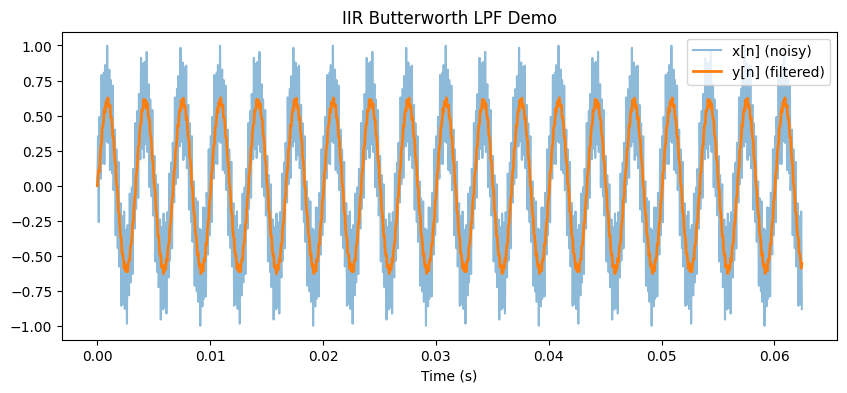

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz

# Design a 2nd-order Butterworth low-pass filter
fs = 16000 # Sampling rate (Hz)
fc = 3000 # Cutoff frequency (Hz)
b, a = butter(2, fc, btype='low', fs=fs)

print("b =", np.round(b, 6))
print("a =", np.round(a, 6))

# Generate test signal
t = np.arange(0, 1, 1/fs)
# Simulated speech component
speech = 0.6 * np.sin(2*np.pi*300*t)
# High-frequency microphone noise
noise = 0.4 * np.sin(2*np.pi*6000*t)
# Combined noisy signal
x = speech + noise

# Apply filter
y = lfilter(b, a, x)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(t[:1000], x[:1000], alpha=0.5, label='x[n] (noisy)')
plt.plot(t[:1000], y[:1000], lw=2, label='y[n] (filtered)')
plt.legend(); plt.xlabel('Time (s)')
plt.title('IIR Butterworth LPF Demo')
plt.show()

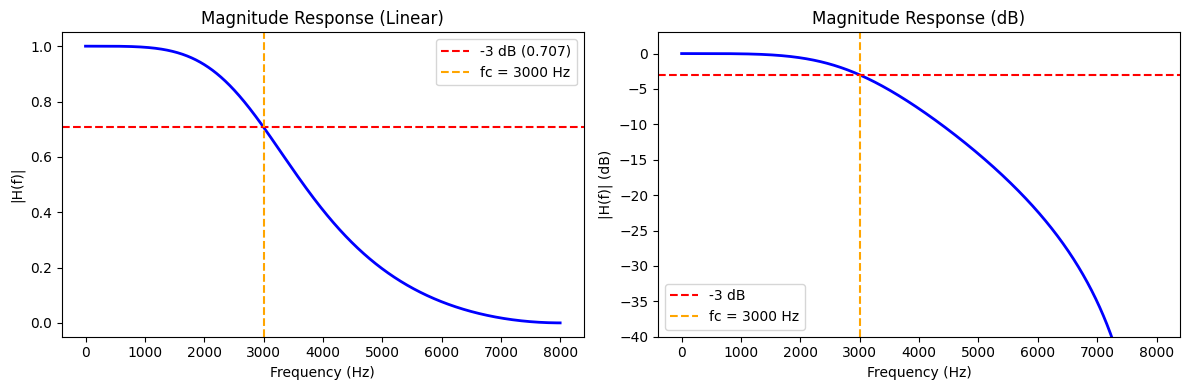

In [2]:
from scipy.signal import freqz

# Compute frequency response
w, H = freqz(b, a, worN=2048, fs=fs)
H_mag = np.abs(H)
H_dB = 20 * np.log10(H_mag + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear scale
axes[0].plot(w, H_mag, 'b', lw=2)
axes[0].axhline(0.707, color='r', ls='--', label='-3 dB (0.707)')
axes[0].axvline(fc, color='orange', ls='--', label=f'fc = {fc} Hz')
axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('|H(f)|')
axes[0].set_title('Magnitude Response (Linear)'); axes[0].legend()

# dB scale (Bode-style)
axes[1].plot(w, H_dB, 'b', lw=2)
axes[1].axhline(-3, color='r', ls='--', label='-3 dB')
axes[1].axvline(fc, color='orange', ls='--', label=f'fc = {fc} Hz')
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('|H(f)| (dB)')
axes[1].set_title('Magnitude Response (dB)'); axes[1].legend()
axes[1].set_ylim(-40, 3)
plt.tight_layout(); plt.show()

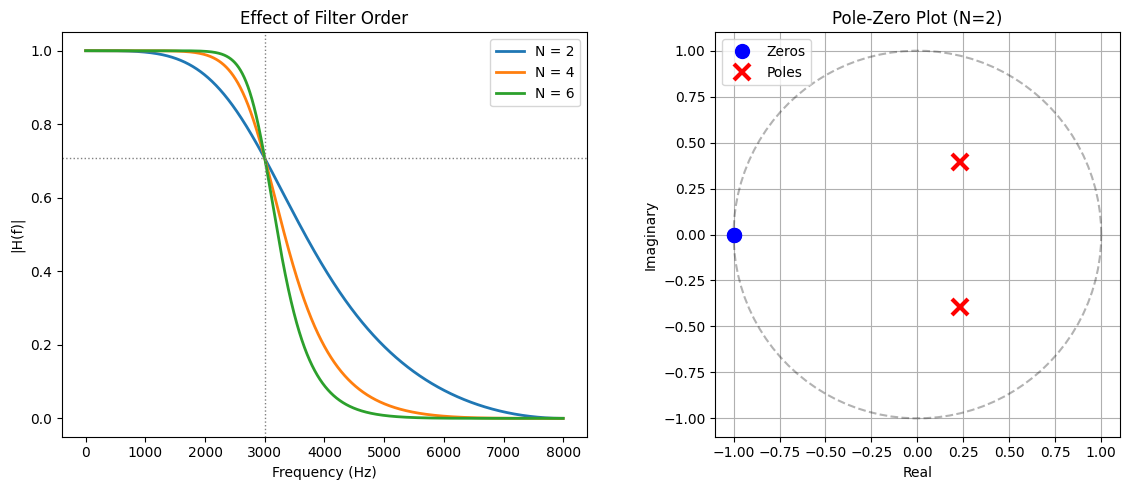

In [3]:
from scipy.signal import tf2zpk

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for order in [2, 4, 6]:
    b_n, a_n = butter(order, fc, btype='low', fs=fs)
    w, H_n = freqz(b_n, a_n, worN=2048, fs=fs)
    axes[0].plot(w, np.abs(H_n), lw=2, label=f'N = {order}')

axes[0].axhline(0.707, color='gray', ls=':', lw=1)
axes[0].axvline(fc, color='gray', ls=':', lw=1)
axes[0].set_xlabel('Frequency (Hz)'); axes[0].set_ylabel('|H(f)|')
axes[0].set_title('Effect of Filter Order'); axes[0].legend()

# Pole-zero plot for N=2
z, p, k = tf2zpk(b, a)
theta = np.linspace(0, 2*np.pi, 100)
axes[1].plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)
axes[1].plot(np.real(z), np.imag(z), 'bo', ms=10, label='Zeros')
axes[1].plot(np.real(p), np.imag(p), 'rx', ms=12, mew=3, label='Poles')
axes[1].set_xlabel('Real'); axes[1].set_ylabel('Imaginary')
axes[1].set_title('Pole-Zero Plot (N=2)'); axes[1].legend()
axes[1].set_aspect('equal'); axes[1].grid(True)

plt.tight_layout(); plt.show()